# Running QAOA (Quantum Approximate Optimization Algorithm) with QLauncher
In this tutorial we will go through a short pipeline of running QAOA (Quantum Approximate Optimization Algorithm) on a custom Hamiltonian with QLauncher: 
1) Defining a custom Hamiltonian 
2) Wrapping it into a QLauncher‑compatible problem class 
3) Defining QAOA
4) Executing QAOA with QLauncher

### 1. Defining a custom Hamiltonian
As an example we will build a Hamiltonian using Qiskit. We will use the representations of a sum of Pauli strings (I, Z, Y, X) with coefficients, stored in a memory‑efficient (sparse) format (SparsePauliOp). It is the standard way Qiskit represents Hamiltonians for simulation and optimization.

In [1]:
from qiskit.quantum_info import SparsePauliOp

# Build Hamiltonian as Qiskit SparsePauliOp class
H = SparsePauliOp.from_list([
    ("II", 1.5),
    ("ZI", -1.0),
    ("ZZ", -0.5)
])

### 2. Wrapping it into a QLauncher‑compatible Problem class
Creating a QLauncher Problem Class simply means wrapping our raw model (like a Hamiltonian) inside a small Python class that inherits from QLauncher’s abstract Problem base class and implements one conversion method, such as to_hamiltonian(), so QLauncher knows how to translate our data into the format required by the chosen algorithm and backend. In practice, this class stores our input (e.g. a SparsePauliOp), exposes it through the correct conversion method, and makes the problem compatible with any algorithm or backend that expects that model type, allowing QLauncher to treat our custom problem as a standardized object that can be optimized, simulated, or executed on different quantum or photonic platforms without changing the rest of the workflow.

In [2]:

from qlauncher.base.models import Hamiltonian

H_ql = Hamiltonian(H)  


### 3. Defining the algorithm 
We define the algorithm which is a part of QLauncher's qiskit routines and create backend. We can specify additional parameters for the QAOA algorithm. The parameter p=2 sets the depth of the QAOA circuit, controlling how many alternating operator layers are applied. A deeper circuit can capture more complex correlations but requires more computational resources. The optimization_method argument specifies the classical optimizer used to tune QAOA’s variational parameters, while max_evaluations limits the number of objective‑function evaluations during the optimization process. 

In [3]:
from qlauncher.routines.qiskit import QAOA, QiskitBackend


algorithm = QAOA(
    p=2,
    optimization_method='COBYLA',
    max_evaluations=200
)

backend = QiskitBackend('local_simulator')



### 4. Executing QAOA with QLauncher

With the algorithm and backend configured, the final step is to submit everything to QLauncher for execution. It acts as a unified interface that bundles together the problem Hamiltonian, optimization routine and backend. This allows you to run the same model across different computational environments with minimal code changes.

In [4]:
from qlauncher import QLauncher

result = QLauncher(H_ql, algorithm, backend).run()
result


Result(bitstring=00, energy=0.0)

We can for example extract the distribution and check which bitstrings have the best results

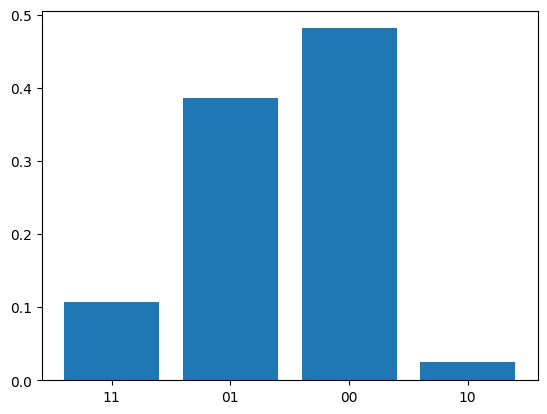

In [5]:
import matplotlib.pyplot as plt

plt.bar(result.distribution.keys(), result.distribution.values())
plt.show()

Result of the QLauncher stores a lot of information apart from the best bitstring, energy and distribution which can be useful to track and assess the algorithm.